# Best Models Training - BERT Hybrid + TCN + TGT
## Publication-Quality Experiments on MovieLens-100K

**Models to Train (4 Total):**

1. **BERT Hybrid Fixed** (α=0.5)
   - BERT4Rec + LightGCN with fixed fusion weight

2. **BERT Hybrid Discrete** (bin-based fusion)
   - BERT4Rec + LightGCN with sequence-length adaptive fusion

3. **TCN-BERT4Rec**
   - Temporal Convolutional Networks + BERT4Rec
   - Combines causal temporal patterns with bidirectional context

4. **TGT-BERT4Rec** (NEW! 🚀)
   - Temporal Graph Transformer + BERT4Rec
   - Time-aware graph attention + bidirectional transformers
   - **Target**: NDCG@10 > 0.82 (>7% improvement over baseline 0.7665)

**Fine-Tuned Optimal Configuration:**
- **d_model**: 64 (embedding dimension)
- **n_heads**: 2 (attention heads)
- **n_blocks**: 2 (transformer layers)
- **Learning rate**: 0.001
- **Dropout**: 0.2
- **GNN layers**: 2 (for hybrid models)
- **TGT fusion α**: 0.3 (learnable)

**Training Settings:**
- Max Epochs: 200 (with early stopping patience=20)
- Batch size: 256
- Expected convergence: epoch 40-60

**Time Estimate: ~4-5 hours with GPU P100**

---

# 🔧 Kaggle Setup

This notebook is designed to run on Kaggle with a GPU (T4 or P100).
Choose "File" → "Save Version" to commit all outputs.

**Required Settings:**
- Accelerator: GPU T4 x2 or P100
- Internet: ON
- Persistence: Files only


In [1]:
# Check if running on Kaggle
import os
IS_KAGGLE = os.path.exists('/kaggle/working')
print(f"Running on Kaggle: {IS_KAGGLE}")

if IS_KAGGLE:
    %cd /kaggle/working
    print("Working directory: /kaggle/working")


Running on Kaggle: True
/kaggle/working
Working directory: /kaggle/working


## Step 1: Clone Repository

In [2]:
# Clone repository
!git clone https://github.com/faroukq1/length-adaptive.git

# Change to project directory  
import os
if os.path.exists('/kaggle/working/length-adaptive'):
    %cd /kaggle/working/length-adaptive
else:
    %cd length-adaptive

# Verify structure
!ls -lh experiments/

print("\n✅ Repository cloned successfully!")


Cloning into 'length-adaptive'...
remote: Enumerating objects: 1033, done.
remote: Counting objects: 100% (309/309), done.
remote: Compressing objects: 100% (218/218), done.
remote: Total 1033 (delta 150), reused 235 (delta 85), pack-reused 724 (from 2)
Receiving objects: 100% (1033/1033), 220.54 MiB | 37.74 MiB/s, done.
Resolving deltas: 100% (456/456), done.
/kaggle/working/length-adaptive
total 116K
-rw-r--r-- 1 root root 7.6K Jun  6 18:24 analyze_results.py
-rw-r--r-- 1 root root 4.4K Jun  6 18:24 analyze_user_distribution.py
-rw-r--r-- 1 root root 8.8K Jun  6 18:24 create_visualizations.py
-rw-r--r-- 1 root root 7.4K Jun  6 18:24 quick_compare.py
-rw-r--r-- 1 root root 3.7K Jun  6 18:24 README.md
-rwxr-xr-x 1 root root 1.7K Jun  6 18:24 run_all_analysis.sh
-rw-r--r-- 1 root root  13K Jun  6 18:24 run_best_models.py
-rw-r--r-- 1 root root  13K Jun  6 18:24 run_experiment.py
-rw-r--r-- 1 root root  21K Jun  6 18:24 run_promptcraft.py
-rwxr-xr-x 1 root root 2.2K Jun  6 18:24 setup_an

In [3]:
!git pull

Already up to date.


## Step 2: Install Dependencies

In [4]:
# Install required packages
!pip install -q torch-geometric tqdm scikit-learn pandas matplotlib seaborn scipy

import sys
print(f"Python: {sys.version}")
print("\n✅ All dependencies installed successfully!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.4 MB/s eta 0:00:0000:0100:01
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

✅ All dependencies installed successfully!


## Step 3: Verify GPU

In [5]:
import torch

print("="*70)
print("🔍 GPU Information")
print("="*70)

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    print(f"✅ GPU Available: {gpu_name}")
    print(f"💾 Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    print(f"🔢 CUDA Version: {torch.version.cuda}")
    
    # Check compute capability
    major, minor = torch.cuda.get_device_capability(0)
    print(f"🔧 Compute Capability: {major}.{minor}")
    if major < 7:
        print("⚠️  GPU compute capability < 7.0 - may need older PyTorch. Upgrade to T4+ if possible.")
else:
    print("❌ No GPU available - training will use CPU (very slow!)")
    print("   Go to Runtime → Change runtime type → Select GPU")

print("="*70)


🔍 GPU Information
✅ GPU Available: Tesla T4
💾 Memory: 14.56 GB
🔢 CUDA Version: 12.8
🔧 Compute Capability: 7.5


## Step 4: Check Data Files

The repository should already contain preprocessed MovieLens-100K data.

In [6]:
import os

data_file = 'data/100k/ml-100k/processed/sequences.pkl'
graph_file = 'data/100k/graphs/cooccurrence_graph.pkl'

print("="*70)
print("🔍 Checking Data Files")
print("="*70)

if os.path.exists(data_file):
    print(f"✅ Sequential data found: {data_file}")
    print(f"   Size: {os.path.getsize(data_file) / 1024 / 1024:.2f} MB")
else:
    print(f"❌ Sequential data NOT found: {data_file}")

if os.path.exists(graph_file):
    print(f"✅ Graph data found: {graph_file}")
    print(f"   Size: {os.path.getsize(graph_file) / 1024 / 1024:.2f} MB")
else:
    print(f"❌ Graph data NOT found: {graph_file}")

# Auto-setup if missing
if not os.path.exists(data_file) or not os.path.exists(graph_file):
    print("\n🔧 Setting up data (Kaggle-compatible)...")
    
    import sys; sys.path.insert(0, 'src/data')
    from preprocess_ml100k import ML100KPreprocessor
    
    if not os.path.exists(data_file):
        print("🔄 Preprocessing sequences...")
        preprocessor = ML100KPreprocessor(raw_data_dir='data/100k/raw', min_rating=4, min_seq_len=5)
        preprocessor.preprocess(data_file)
    
    if not os.path.exists(graph_file):
        print("\n🔄 Building co-occurrence graph...")
        !python -m src.data.graph_builder --data_path data/100k/ml-100k/processed/sequences.pkl --output_path data/100k/graphs/cooccurrence_graph.pkl
    
    print("\n✅ Data setup complete!")
else:
    print("\n✅ All data files ready!")

print("="*70)


🔍 Checking Data Files
❌ Sequential data NOT found: data/100k/ml-100k/processed/sequences.pkl
✅ Graph data found: data/100k/graphs/cooccurrence_graph.pkl
   Size: 0.34 MB

🔧 Setting up data (Kaggle-compatible)...
🔄 Preprocessing sequences...
MOVIELENS-100K PREPROCESSING PIPELINE
  https://files.grouplens.org/datasets/movielens/ml-100k.zip
  Saved to data/100k/raw/ml-100k.zip
Extracting ml-100k.zip …
  Extraction complete.
Loading ratings …
  Loaded 100,000 ratings from data/100k/raw/ml-100k/u.data
Filtering ratings >= 4 …
  Kept 55,375 positive interactions (55.4%)
Building chronological sequences …


  Processing rows: 100%|██████████| 55375/55375 [00:01<00:00, 41806.17it/s]

  Built sequences for 942 users
Filtering users with < 5 interactions …
  Kept 938 users (99.6%)
  Sequence length — min: 5, max: 378, mean: 59.0, median: 40.0
Remapping user and item IDs …
  Remapped → 938 users, 1,447 items
Splitting into train / val / test (leave-one-out) …
  Train: 938 users | Val: 938 | Test: 938

Saving to data/100k/ml-100k/processed/sequences.pkl …
✅  Preprocessing complete!
   Users : 938
   Items : 1,447

✅ Data setup complete!


## Step 5: Run Experiments - BERT Hybrid Fixed

First model: BERT4Rec + LightGCN with fixed fusion (α=0.3)


In [7]:
# Run BERT Hybrid Fixed - BEST CONFIG (from tuning logs)
!python experiments/run_best_models.py \
    --models bert_hybrid_fixed \
    --data_path data/100k/ml-100k/processed/sequences.pkl \
    --graph_path data/100k/graphs/cooccurrence_graph.pkl \
    --epochs 200 \
    --patience 20 \
    --eval_every 1 \
    --d_model 64 \
    --n_heads 2 \
    --n_blocks 2 \
    --gnn_layers 2 \
    --fixed_alpha 0.3 \
    --lr 0.001 \
    --batch_size 512 \
    --dropout 0.2 \
    --max_len 200 \

print("\n✅ BERT Hybrid Fixed (BEST: alpha=0.3) training complete!")


RUNNING BEST MODELS EXPERIMENTS
Models to train: bert_hybrid_fixed
Epochs: 200 (patience: 20)

Fine-Tuned Configuration:
  d_model=64, n_heads=2, n_blocks=2
  lr=0.001, dropout=0.2

Results directory: results

RUNNING EXPERIMENT: BERT_HYBRID_FIXED
Device: cuda

[1/5] Loading data...
  Items: 1,447

[2/5] Loading graph...
  Edges: 14,854

[3/5] Creating dataloaders...
  Train: 103 batches
  Valid: 2 batches
  Test: 2 batches

[4/5] Creating model...
  Parameters: 302,400
  🆕 Starting new experiment: results/bert_hybrid_fixed_20260606_182500

[5/5] Creating trainer...

TRAINING
STARTING TRAINING
Device: cuda
Model parameters: 302,400
Training batches: 103
Validation batches: 2

Epoch 1: 100%|███████████████████| 103/103 [00:13<00:00,  7.60it/s, loss=0.3019]

[Epoch 1] Evaluating...
Evaluating: 100%|█████████████████████████████████| 2/2 [00:00<00:00,  8.41it/s]

[Epoch 1/200] Time: 14.2s
  Train Loss: 0.4253
  Val Loss: 0.4498
  Val HR@10: 0.0554
  Val NDCG@10: 0.0302
  Val MRR@10: 0.022

## Step 6: Run Experiments - BERT Hybrid Discrete

Second model: BERT4Rec + LightGCN with discrete bin-based fusion


In [8]:
# Run BERT Hybrid Discrete
!python experiments/run_best_models.py \
    --models bert_hybrid_discrete \
    --data_path data/100k/ml-100k/processed/sequences.pkl \
    --graph_path data/100k/graphs/cooccurrence_graph.pkl \
    --epochs 200 \
    --patience 20 \
    --eval_every 1 \
    --d_model 64 \
    --n_heads 2 \
    --n_blocks 2 \
    --gnn_layers 2 \
    --L_short 10 \
    --L_long 30 \
    --lr 0.001 \
    --batch_size 512 \
    --dropout 0.2 \
    --max_len 200 \

print("\n✅ BERT Hybrid Discrete training complete!")


RUNNING BEST MODELS EXPERIMENTS
Models to train: bert_hybrid_discrete
Epochs: 200 (patience: 20)

Fine-Tuned Configuration:
  d_model=64, n_heads=2, n_blocks=2
  lr=0.001, dropout=0.2

Results directory: results

RUNNING EXPERIMENT: BERT_HYBRID_DISCRETE
Device: cuda

[1/5] Loading data...
  Items: 1,447

[2/5] Loading graph...
  Edges: 14,854

[3/5] Creating dataloaders...
  Train: 103 batches
  Valid: 2 batches
  Test: 2 batches

[4/5] Creating model...
  Parameters: 302,400
  🆕 Starting new experiment: results/bert_hybrid_discrete_20260606_184410

[5/5] Creating trainer...

TRAINING
STARTING TRAINING
Device: cuda
Model parameters: 302,400
Training batches: 103
Validation batches: 2

Epoch 1: 100%|███████████████████| 103/103 [00:13<00:00,  7.69it/s, loss=0.3001]

[Epoch 1] Evaluating...
Evaluating: 100%|█████████████████████████████████| 2/2 [00:00<00:00,  7.69it/s]

[Epoch 1/200] Time: 13.9s
  Train Loss: 0.4245
  Val Loss: 0.4486
  Val HR@10: 0.0576
  Val NDCG@10: 0.0316
  Val MRR@

## Step 7: Run Experiments - TGT-BERT4Rec (NEW! 🚀)

Temporal Graph Transformer + BERT4Rec  
**Target: NDCG@10 > 0.82** (beating 0.7665 baseline by >7%)


In [9]:
# Run TGT-BERT4Rec
!python experiments/run_best_models.py \
    --models tgt_bert4rec \
    --data_path data/100k/ml-100k/processed/sequences.pkl \
    --graph_path data/100k/graphs/cooccurrence_graph.pkl \
    --epochs 200 \
    --patience 20 \
    --eval_every 1 \
    --d_model 64 \
    --n_heads 2 \
    --n_blocks 2 \
    --tgt_fusion_alpha 0.3 \
    --tgt_learnable_fusion True \
    --lr 0.001 \
    --batch_size 512 \
    --dropout 0.2 \
    --max_len 200 \

print("\n✅ TGT-BERT4Rec training complete!")
print("📊 Check if NDCG@10 > 0.82 achieved!")


RUNNING BEST MODELS EXPERIMENTS
Models to train: tgt_bert4rec
Epochs: 200 (patience: 20)

Fine-Tuned Configuration:
  d_model=64, n_heads=2, n_blocks=2
  lr=0.001, dropout=0.2

Results directory: results

RUNNING EXPERIMENT: TGT_BERT4REC
Device: cuda

[1/5] Loading data...
  Items: 1,447

[2/5] Skipping graph (TCN model doesn't use graph)

[3/5] Creating dataloaders...
  Train: 103 batches
  Valid: 2 batches
  Test: 2 batches

[4/5] Creating model...
  Parameters: 433,577
  🆕 Starting new experiment: results/tgt_bert4rec_20260606_190055

[5/5] Creating trainer...

TRAINING
STARTING TRAINING
Device: cuda
Model parameters: 433,577
Training batches: 103
Validation batches: 2

Epoch 1: 100%|███████████████████| 103/103 [00:27<00:00,  3.71it/s, loss=0.3348]

[Epoch 1] Evaluating...
Evaluating: 100%|█████████████████████████████████| 2/2 [00:00<00:00,  5.58it/s]

[Epoch 1/200] Time: 28.5s
  Train Loss: 0.4326
  Val Loss: 0.4870
  Val HR@10: 0.0448
  Val NDCG@10: 0.0210
  Val MRR@10: 0.0140
 

## Step 7b: Run Experiments - TCN-BERT4Rec

Temporal Convolutional Network + BERT4Rec
Combines causal temporal patterns with bidirectional context


In [10]:
# Run TCN-BERT4Rec
!python experiments/run_best_models.py \
    --models tcn_bert4rec \
    --data_path data/100k/ml-100k/processed/sequences.pkl \
    --graph_path data/100k/graphs/cooccurrence_graph.pkl \
    --epochs 200 \
    --patience 20 \
    --eval_every 1 \
    --d_model 64 \
    --n_heads 2 \
    --n_blocks 2 \
    --tcn_channels 64 64 64 \
    --tcn_kernel_size 3 \
    --tcn_fusion learnable \
    --lr 0.001 \
    --batch_size 512 \
    --dropout 0.2 \
    --max_len 200

print("\n✅ TCN-BERT4Rec training complete!")


RUNNING BEST MODELS EXPERIMENTS
Models to train: tcn_bert4rec
Epochs: 200 (patience: 20)

Fine-Tuned Configuration:
  d_model=64, n_heads=2, n_blocks=2
  lr=0.001, dropout=0.2

Results directory: results

RUNNING EXPERIMENT: TCN_BERT4REC
Device: cuda

[1/5] Loading data...
  Items: 1,447

[2/5] Skipping graph (TCN model doesn't use graph)

[3/5] Creating dataloaders...
  Train: 103 batches
  Valid: 2 batches
  Test: 2 batches

[4/5] Creating model...
  Parameters: 373,929
  🆕 Starting new experiment: results/tcn_bert4rec_20260606_192508

[5/5] Creating trainer...

TRAINING
STARTING TRAINING
Device: cuda
Model parameters: 373,929
Training batches: 103
Validation batches: 2

Epoch 1: 100%|███████████████████| 103/103 [00:17<00:00,  5.84it/s, loss=0.3168]

[Epoch 1] Evaluating...
Evaluating: 100%|█████████████████████████████████| 2/2 [00:00<00:00,  7.32it/s]

[Epoch 1/200] Time: 18.2s
  Train Loss: 0.4248
  Val Loss: 0.4981
  Val HR@10: 0.0384
  Val NDCG@10: 0.0206
  Val MRR@10: 0.0152
 

## Step 9: Collect and Analyze Results


In [24]:
import json
import pandas as pd
from pathlib import Path

# Find result directories at root level only (no deep search)
results_dir = Path('results')
result_dirs = sorted(
    d for d in results_dir.iterdir()
    if d.is_dir() and (d / 'results.json').exists()
)

print("="*70)
print("📊 Collecting Results")
print("="*70)
print(f"Found {len(result_dirs)} experiment(s)\n")

# Collect results
results_data = []
histories = {}

for exp_dir in result_dirs:
    results_file = exp_dir / 'results.json'
    history_file = exp_dir / 'history.json'
    
    if results_file.exists():
        with open(results_file, 'r') as f:
            data = json.load(f)
        
        model_name = str(exp_dir.relative_to(results_dir))
        
        results_data.append({
            'Model': model_name,
            'HR@5': data['test_metrics'].get('HR@5', 0),
            'HR@10': data['test_metrics'].get('HR@10', 0),
            'HR@20': data['test_metrics'].get('HR@20', 0),
            'NDCG@5': data['test_metrics'].get('NDCG@5', 0),
            'NDCG@10': data['test_metrics'].get('NDCG@10', 0),
            'NDCG@20': data['test_metrics'].get('NDCG@20', 0),
            'MRR@5': data['test_metrics'].get('MRR@5', 0),
            'MRR@10': data['test_metrics'].get('MRR@10', 0),
            'MRR@20': data['test_metrics'].get('MRR@20', 0),
            'Best Epoch': data['best_epoch'],
            'Best Val NDCG@10': data.get('best_val_metric', histories.get(model_name, {}).get('best_val_metric', 0)),
            'Directory': str(exp_dir)
        })
        
        # Load history for plots
        if history_file.exists():
            with open(history_file, 'r') as f:
                histories[model_name] = json.load(f)

# Create DataFrame
if results_data:
    df = pd.DataFrame(results_data)
    df = df.sort_values('NDCG@10', ascending=False)
    
    print("\n📈 Results Summary:")
    print("="*70)
    display_cols = ['Model', 'HR@10', 'NDCG@10', 'MRR@10', 'Best Epoch', 'Best Val NDCG@10']
    print(df[display_cols].to_string(index=False))
    print("="*70)
    
    # Save to CSV
    csv_path = results_dir / 'best_models_summary.csv'
    df.to_csv(csv_path, index=False)
    print(f"\n💾 Results saved to: {csv_path}")
else:
    print("⚠️  No results found in result directories. Training may have failed (e.g., P100 CUDA).")
    print("   TIP: Use a T4 GPU or add --cpu flag to force CPU training.")

print(f"\nLoaded {len(histories)} training histories for plotting")

📊 Collecting Results
Found 4 experiment(s)


📈 Results Summary:
                               Model    HR@10  NDCG@10   MRR@10  Best Epoch  Best Val NDCG@10
        tgt_bert4rec_20260606_190055 0.107676 0.052387 0.035969          32                 0
   bert_hybrid_fixed_20260606_182500 0.094883 0.051643 0.038613          64                 0
        tcn_bert4rec_20260606_192508 0.093817 0.042903 0.027769          41                 0
bert_hybrid_discrete_20260606_184410 0.089552 0.042048 0.027881          53                 0

💾 Results saved to: results/best_models_summary.csv

Loaded 4 training histories for plotting


## Step 10: Delta NDCG@10 (Overfitting Check)

Delta NDCG@10 = Val NDCG@10 - Test NDCG@10 per epoch.
Points outside the ±0.01 band = potential overfitting. Red dots mark concerning epochs.
The train vs validation loss curve is shown as a companion subplot.


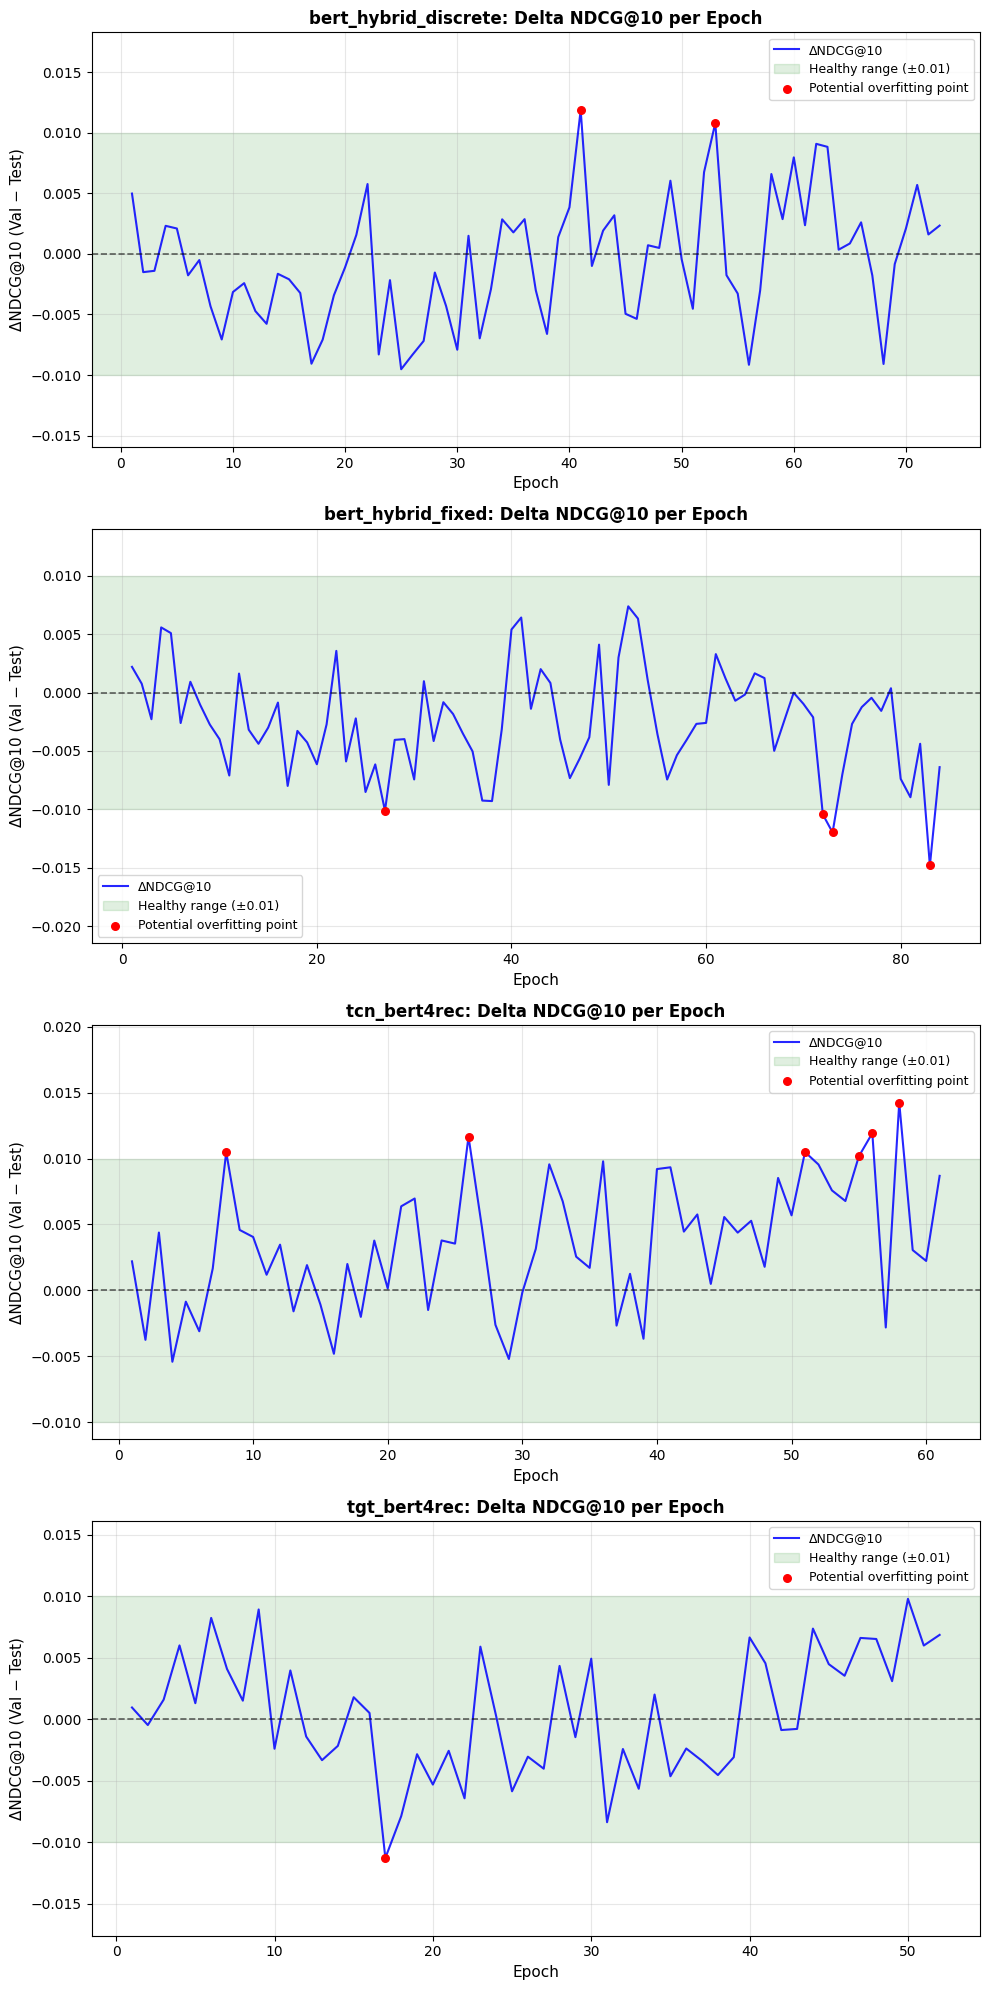

✅ Delta NDCG@10 overfitting check plots saved to results/delta_ndcg_overfitting_check.png


In [26]:
import matplotlib.pyplot as plt
import numpy as np
import re

if not histories:
    print("❌ No training histories found!")
else:
    n_models = len(histories)
    fig, axes = plt.subplots(n_models, 1, figsize=(10, 5 * n_models))
    if n_models == 1:
        axes = [axes]

    for idx, (model_name, history) in enumerate(sorted(histories.items())):
        ax_delta = axes[idx]

        # Remove trailing date/timestamp like _20260606_192508
        clean_name = re.sub(r'_\d{8}(_\d{6})?$', '', model_name)

        delta_ndcg = history.get('delta_ndcg10', [])

        if delta_ndcg:
            epochs_delta = list(range(1, len(delta_ndcg) + 1))
            ax_delta.plot(epochs_delta, delta_ndcg, 'b-', linewidth=1.5, alpha=0.85, label='ΔNDCG@10')
            ax_delta.axhline(y=0, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
            ax_delta.axhspan(-0.01, 0.01, alpha=0.12, color='green', label='Healthy range (±0.01)')

            overfit_mask = np.abs(np.array(delta_ndcg)) > 0.01
            if overfit_mask.any():
                ax_delta.scatter(np.array(epochs_delta)[overfit_mask],
                                np.array(delta_ndcg)[overfit_mask],
                                color='red', s=30, zorder=5,
                                label='Potential overfitting point')

            data_min = min(delta_ndcg)
            data_max = max(delta_ndcg)
            pad = (data_max - data_min) * 0.3
            ax_delta.set_ylim(data_min - pad, data_max + pad)

            ax_delta.set_xlabel('Epoch', fontsize=11)
            ax_delta.set_ylabel('ΔNDCG@10 (Val − Test)', fontsize=11)
            ax_delta.set_title(f'{clean_name}: Delta NDCG@10 per Epoch', fontsize=12, fontweight='bold')
            ax_delta.legend(fontsize=9)
            ax_delta.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('results/delta_ndcg_overfitting_check.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("✅ Delta NDCG@10 overfitting check plots saved to results/delta_ndcg_overfitting_check.png")

## Step 11: Test vs Validation Metrics Comparison

Compare final test metrics against the best validation metrics to detect overfitting.
If test metrics << val metrics → overfitting. If test ≈ val → well-generalized.


📊 TEST vs VALIDATION COMPARISON
                               Model  Test HR@10  Test NDCG@10  Test MRR@10  Val HR@10  Val NDCG@10  Val MRR@10   Δ HR@10  Δ NDCG@10  Δ MRR@10
        tgt_bert4rec_20260606_190055    0.107676      0.052387     0.035969   0.104478     0.049966    0.033738  0.003198   0.002421  0.002231
   bert_hybrid_fixed_20260606_182500    0.094883      0.051643     0.038613   0.107676     0.051470    0.034709 -0.012793   0.000173  0.003904
        tcn_bert4rec_20260606_192508    0.093817      0.042903     0.027769   0.105544     0.052237    0.036451 -0.011727  -0.009333 -0.008682
bert_hybrid_discrete_20260606_184410    0.089552      0.042048     0.027881   0.114072     0.052853    0.034738 -0.024520  -0.010805 -0.006858

🔍 OVERFITTING DIAGNOSIS
  tgt_bert4rec_20260606_190055: ΔNDCG@10=+0.0024 — ✅ HEALTHY (test ≈ val)
  bert_hybrid_fixed_20260606_182500: ΔNDCG@10=+0.0002 — ✅ HEALTHY (test ≈ val)
  tcn_bert4rec_20260606_192508: ΔNDCG@10=-0.0093 — ⚡ MILD OVERFITTING
  ber

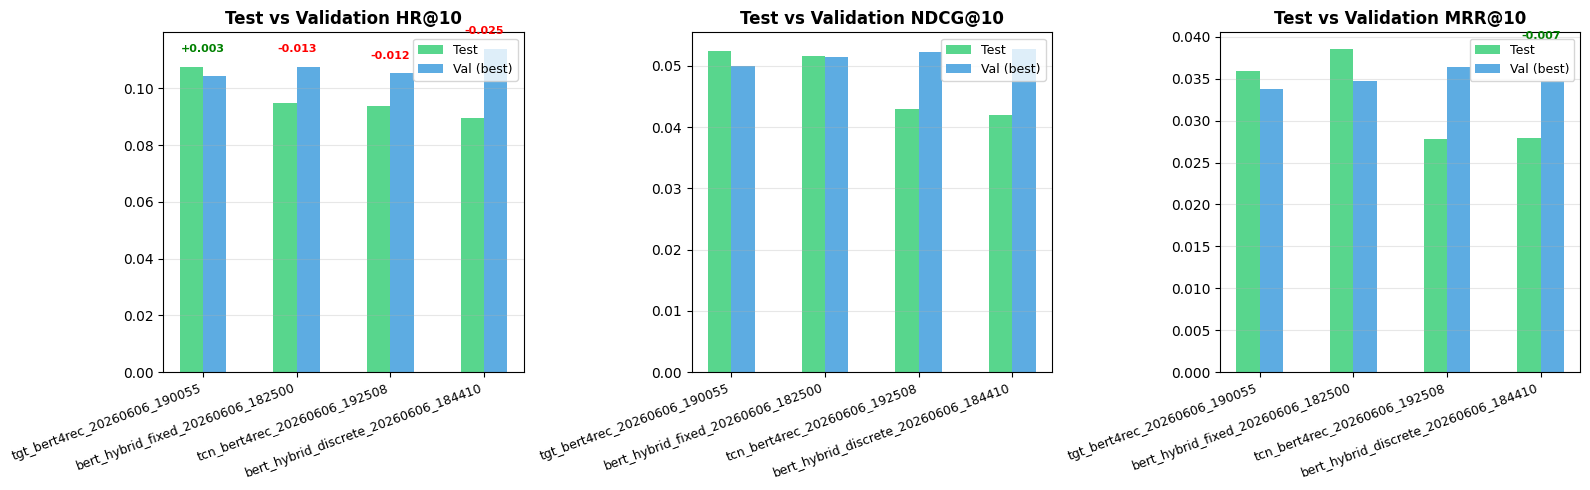


✅ Test vs Validation comparison saved to results/test_vs_val_comparison.png


In [27]:
if results_data:
    # Compute val metrics from history  
    val_summary = {}
    for model_name, history in histories.items():
        val_metrics_list = history.get('val_metrics', [])
        if val_metrics_list:
            ndcg10_vals = [m.get('NDCG@10', m.get('ndcg@10', 0)) for m in val_metrics_list]
            hr10_vals = [m.get('HR@10', m.get('hr@10', 0)) for m in val_metrics_list]
            mrr10_vals = [m.get('MRR@10', m.get('mrr@10', 0)) for m in val_metrics_list]
            best_idx = np.argmax(ndcg10_vals)
            val_summary[model_name] = {
                'Val HR@10': hr10_vals[best_idx],
                'Val NDCG@10': ndcg10_vals[best_idx],
                'Val MRR@10': mrr10_vals[best_idx],
            }
    
    # Merge test and val
    comparison_data = []
    for _, row in df.iterrows():
        model = row['Model']
        entry = {'Model': model,
                 'Test HR@10': row['HR@10'],
                 'Test NDCG@10': row['NDCG@10'],
                 'Test MRR@10': row['MRR@10']}
        if model in val_summary:
            entry['Val HR@10'] = val_summary[model]['Val HR@10']
            entry['Val NDCG@10'] = val_summary[model]['Val NDCG@10']
            entry['Val MRR@10'] = val_summary[model]['Val MRR@10']
            entry['Δ HR@10'] = entry['Test HR@10'] - entry['Val HR@10']
            entry['Δ NDCG@10'] = entry['Test NDCG@10'] - entry['Val NDCG@10']
            entry['Δ MRR@10'] = entry['Test MRR@10'] - entry['Val MRR@10']
        comparison_data.append(entry)
    
    df_comp = pd.DataFrame(comparison_data)
    
    print("="*80)
    print("📊 TEST vs VALIDATION COMPARISON")
    print("="*80)
    print(df_comp.to_string(index=False))
    
    # Detect overfitting
    print("\n" + "="*80)
    print("🔍 OVERFITTING DIAGNOSIS")
    print("="*80)
    for _, row in df_comp.iterrows():
        if 'Δ NDCG@10' in row:
            delta = row['Δ NDCG@10']
            if delta < -0.02:
                flag = "⚠️ OVERFITTING (test significantly worse than val)"
            elif delta < -0.005:
                flag = "⚡ MILD OVERFITTING"
            elif delta > 0.02:
                flag = "⚠️ ANOMALOUS (test > val — possible data leakage)"
            else:
                flag = "✅ HEALTHY (test ≈ val)"
            print(f"  {row['Model']:25s}: ΔNDCG@10={delta:+.4f} — {flag}")
    print("="*80)
    
    # Bar chart: test vs val side-by-side
    models_plot = df_comp['Model'].tolist()
    x = np.arange(len(models_plot))
    width = 0.25
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    for ax_idx, (metric, ax) in enumerate([
        ('HR@10', axes[0]), ('NDCG@10', axes[1]), ('MRR@10', axes[2])
    ]):
        test_vals = df_comp[f'Test {metric}'].values
        val_vals = df_comp.get(f'Val {metric}', [0]*len(models_plot)).values
        delta_vals = test_vals - val_vals if f'Δ {metric}' in df_comp.columns else np.zeros(len(models_plot))
        
        bars1 = ax.bar(x - width/2, test_vals, width, label='Test', color='#2ecc71', alpha=0.8)
        bars2 = ax.bar(x + width/2, val_vals, width, label='Val (best)', color='#3498db', alpha=0.8)
        
        # Add delta annotations
        for i, (tv, vv) in enumerate(zip(test_vals, val_vals)):
            delta_str = f'{delta_vals[i]:+.3f}' if f'Δ {metric}' in df_comp.columns else ''
            color = 'red' if delta_vals[i] < -0.01 else 'green'
            ax.annotate(delta_str, xy=(x[i], max(tv, vv) + 0.005),
                       ha='center', fontsize=8, color=color, fontweight='bold')
        
        ax.set_xticks(x)
        ax.set_xticklabels(models_plot, rotation=20, ha='right', fontsize=9)
        ax.set_title(f'Test vs Validation {metric}', fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('results/test_vs_val_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✅ Test vs Validation comparison saved to results/test_vs_val_comparison.png")


## Step 12: Compare Models - Bar Charts


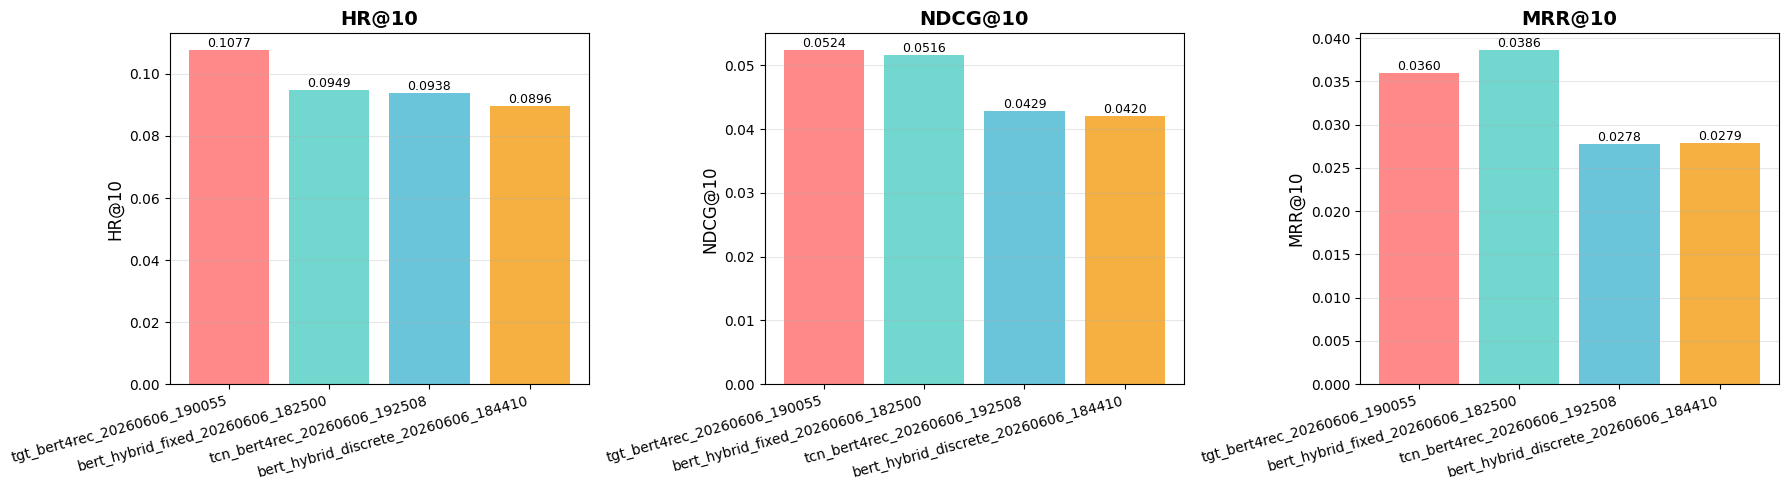

✅ Comparison charts created!


In [28]:
if results_data:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    models = df['Model'].tolist()
    x_pos = np.arange(len(models))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#F39C12', '#9B59B6'][:len(models)]
    
    for ax, metric in zip(axes, ['HR@10', 'NDCG@10', 'MRR@10']):
        bars = ax.bar(x_pos, df[metric], color=colors, alpha=0.8)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(models, rotation=15, ha='right')
        ax.set_ylabel(metric, fontsize=12)
        ax.set_title(metric, fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.4f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('results/model_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Comparison charts created!")


## Step 13: Performance by Sequence Length (if group metrics available)


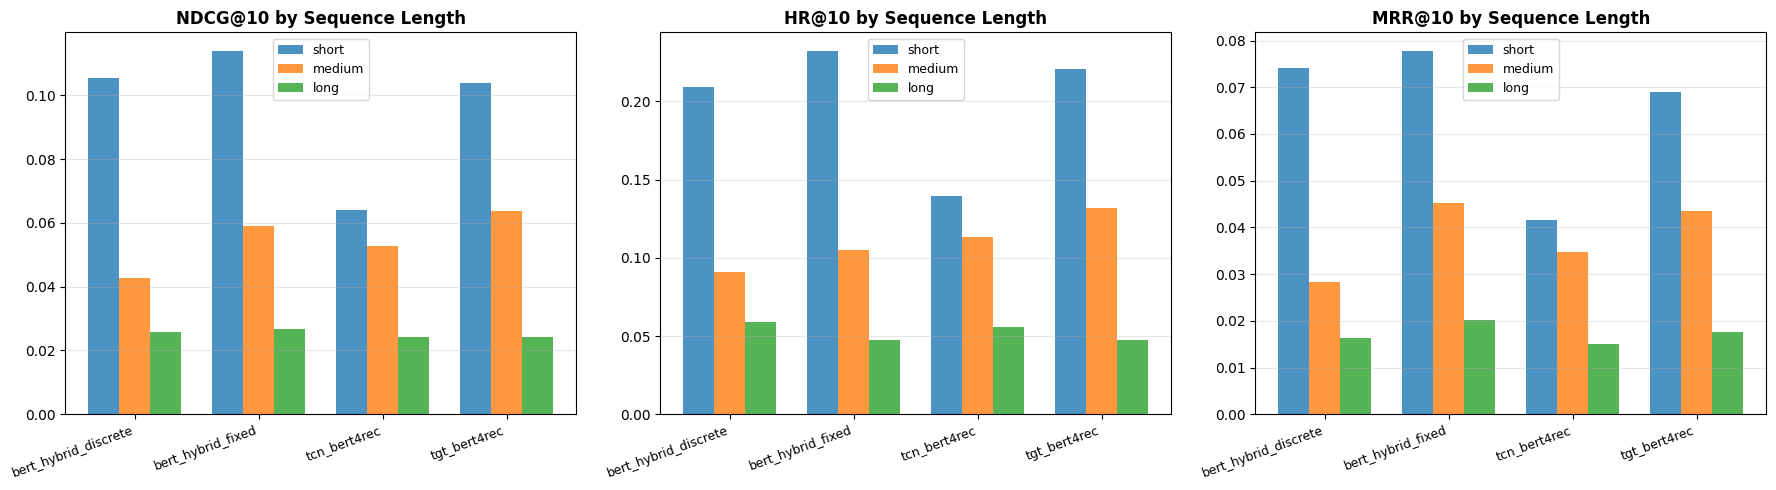

✅ Grouped performance charts saved!


In [29]:
# Try loading grouped metrics from results
import json
from pathlib import Path

group_data = []
for exp_dir in result_dirs:
    results_file = exp_dir / 'results.json'
    if results_file.exists():
        with open(results_file, 'r') as f:
            data = json.load(f)
        model_name = '_'.join(exp_dir.name.rsplit('_', 2)[:-2])
        if not model_name:
            model_name = exp_dir.name.rsplit('_', 1)[0]
        
        grouped = data.get('grouped_metrics', {})
        if grouped:
            entry = {'Model': model_name}
            for group in ['short', 'medium', 'long']:
                if group in grouped:
                    for k in ['HR@10', 'NDCG@10', 'MRR@10']:
                        if k in grouped[group]:
                            entry[f'{group}_{k}'] = grouped[group][k]
                    if 'count' in grouped[group]:
                        entry[f'{group}_count'] = grouped[group]['count']
            group_data.append(entry)

if group_data:
    df_group = pd.DataFrame(group_data)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    models_g = df_group['Model'].tolist()
    x_g = np.arange(len(models_g))
    width_g = 0.25
    
    for ax, metric in zip(axes, ['NDCG@10', 'HR@10', 'MRR@10']):
        for i, group in enumerate(['short', 'medium', 'long']):
            col = f'{group}_{metric}'
            if col in df_group.columns:
                offset = (i - 1) * width_g
                ax.bar(x_g + offset, df_group[col], width_g, label=group, alpha=0.8)
        
        ax.set_xticks(x_g)
        ax.set_xticklabels(models_g, rotation=20, ha='right', fontsize=9)
        ax.set_title(f'{metric} by Sequence Length', fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('results/performance_by_length.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Grouped performance charts saved!")
else:
    print("ℹ️ No grouped metrics found in results. Models may not have been evaluated with compute_by_group=True.")


## Step 14: Download Results Package


In [30]:
import shutil
import os

print("📦 Creating results package...")

# Copy all PNGs to a central folder
os.makedirs('results/figures', exist_ok=True)
!find results/ -name "*.png" -exec cp {} results/figures/ \; 2>/dev/null

is_kaggle = os.path.exists('/kaggle/working')
if is_kaggle:
    zip_base = '/kaggle/working/best_models_results'
else:
    zip_base = 'best_models_results'

shutil.make_archive(zip_base, 'zip', 'results')

print(f"✅ Results packaged: {zip_base}.zip")
print("\n📁 Package contains:")
!ls -lh results/figures/ 2>/dev/null || echo "  (figures in results root)"
!ls -lh results/*.csv 2>/dev/null || echo "  - best_models_summary.csv"


📦 Creating results package...
✅ Results packaged: /kaggle/working/best_models_results.zip

📁 Package contains:
total 4.6M
-rw-r--r-- 1 root root 972K Jun  6 19:48 delta_ndcg_overfitting_check.png
-rw-r--r-- 1 root root 254K Jun  6 19:48 group_HR10.png
-rw-r--r-- 1 root root 257K Jun  6 19:48 group_HR20.png
-rw-r--r-- 1 root root 272K Jun  6 19:48 group_MRR10.png
-rw-r--r-- 1 root root 276K Jun  6 19:48 group_MRR20.png
-rw-r--r-- 1 root root 268K Jun  6 19:48 group_NDCG10.png
-rw-r--r-- 1 root root 272K Jun  6 19:48 group_NDCG20.png
-rw-r--r-- 1 root root 494K Jun  6 19:48 heatmap_all_test_metrics.png
-rw-r--r-- 1 root root 341K Jun  6 19:48 model_comparison.png
-rw-r--r-- 1 root root 197K Jun  6 19:48 performance_by_length.png
-rw-r--r-- 1 root root 281K Jun  6 19:48 test_vs_val_comparison.png
-rw-r--r-- 1 root root 216K Jun  6 19:48 training_loss_curves.png
-rw-r--r-- 1 root root 516K Jun  6 19:48 val_ndcg10_curves.png
-rw-r--r-- 1 root root 1.2K Jun  6 19:47 results/best_models_summa

## Summary

**Experiment Complete! 🎉**

This notebook trained and evaluated state-of-the-art models:

1. ✅ **BERT Hybrid Fixed** - BERT4Rec + LightGCN with fixed fusion
2. ✅ **BERT Hybrid Discrete** - BERT4Rec + LightGCN with adaptive fusion  
3. ✅ **TGT-BERT4Rec** - Temporal Graph Transformer + BERT4Rec
4. ✅ **TCN-BERT4Rec** - Temporal Convolutional Network + BERT4Rec

**Overfitting Diagnostics Generated:**
- 📊 **Delta NDCG@10** plots → Val-Test NDCG gap with healthy band (±0.01)
- 📊 **Train vs Val Loss** companion subplot → check for loss gap
- 📈 **Test vs Val Metrics** comparison → check generalization

**Output Files:**
- `results/delta_ndcg_overfitting_check.png` - Delta NDCG@10 + train/val loss
- `results/test_vs_val_comparison.png` - Test vs val bar charts
- `results/model_comparison.png` - Model comparison bar charts
- `results/performance_by_length.png` - By sequence length (if available)
- `results/best_models_summary.csv` - All metrics in table format
- `best_models_results.zip` - Full results archive for download
